# Генерація тексту

У цій роботі ми використаємо мовну модель для генерації тексту.

У класичної мовної моделі є два взаємопов'язані визначення:

1. Оцінити ймовірність вхідного тексту.
2. Видати ймовірнісний розподіл наступного слова для даного префіксу.

Для генерації тексту нам ідеально підходить друге визначення.

## Початок роботи

Будь ласка, заповніть поля `EMAIL`, `NAME` та `GROUP` нижче:

In [58]:
!pip install --quiet --ignore-installed https://static.lp-nlp.com/pypi/lpnlp-2026.10.1-py3-none-any.whl

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [59]:
################################################################################
# FILL-IN:
#-----------------------------------------------------------------------
EMAIL = "daniil.shevchenko.shi.2023@lpnu.ua"  # заповніть вашим значенням
################################################################################

import lpnlp

lab = lpnlp.start(email=EMAIL, lab="text_generation")

Удачі!


### Завантаження моделі

Тренування мовної моделі з нуля займає багато часу: від кількох годин або днів для маленьких та середніх моделей й аж до кількох місяців чи навіть років для великих. Звичайно, за рахунок розпаралелювання тренування на багатьох GPU, реальний час рідко буває більше місяця-двох.

Для цієї роботи (як і в реальному житті), ми візьмемо претреновану модель. Хтось натренував її за нас. В данному випадку, візьмемо GPT-2 від компанії OpenAI.

Ця модель, як і безліч інших, зберігається на [HuggingFace Models](https://huggingface.co/models). Завантажити та працювати з нею зручно через бібліотеку [HuggingFace Transformers](https://github.com/huggingface/transformers/)

In [60]:
!pip install --quiet transformers

In [61]:
import transformers
import torch

In [62]:
model = transformers.AutoModelForCausalLM.from_pretrained("gpt2")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

## Токенізація

Кожна модель має словник токенів, з яким вона тренувалася, та правила токенізації (розбиття тексту на токени). Обов'язково слід використовувати той самий словник та метод.

Бібліотека transformers вміє робити це для кожної підтримуваної моделі.

In [63]:
tokenizer = transformers.AutoTokenizer.from_pretrained("gpt2")

Перевіримо токенізатор:

In [64]:
input_text = "Hello, LP NLP!"
token_ids = tokenizer.encode(input_text)
token_ids

[15496, 11, 18470, 399, 19930, 0]

In [65]:
tokenizer.convert_ids_to_tokens(token_ids)

['Hello', ',', 'ĠLP', 'ĠN', 'LP', '!']

Рідкісні слова будуть розбиті на підслова:

In [66]:
tokenizer.convert_ids_to_tokens(tokenizer.encode("My name is Oleksiy Syvokon"))

['My', 'Ġname', 'Ġis', 'ĠOle', 'ks', 'iy', 'ĠSy', 'v', 'ok', 'on']

## Перевірка моделі -- один крок ітерації

Ми генеруватимемо текст в циклі токен за токеном, зліва направо. Але для початку розберімо, як виглядає один крок такого циклу.


На кожному кроці на вхід моделі подаємо ті токени, які вже згенеровано.

На першому кроці у нас ще нічого не згенеровано. Тому починаємо зі токену `<BOS>` ("begin of sentence"). В різних моделях він виглядає по-різному. Подивимося, що в GPT-2:


In [67]:
tokenizer.bos_token

'<|endoftext|>'

In [68]:
tokenizer.bos_token_id

50256

In [69]:
# Формуємо вхідний батч. Майже завжди для більшої ефективності
# нейронні мережі очікують на вхід кілька незалежних речень
# (або зображень у випадку з комп'ютерним зором)
#
# В нашій роботі ми завжди працюємо лише з одним реченням,
# тож розмір батча дорівнює одинці. Але все одно маємо
# оформити вхід як матрицю:
input_ = torch.LongTensor([[tokenizer.bos_token_id]])
input_

tensor([[50256]])

In [70]:
# Нарешті робимо крок генерації
output = model(input_, return_dict=True)

# На виході модель повертає вектор з logits -- ненормалізованими
# ймовірностями кожного токена в словнику
output.logits.shape

torch.Size([1, 1, 50257])

Чому маємо саме таку розмірність?

* Перша одиниця -- розмір батча, тобто кількість вхідних речень.
* Друга одиниця -- це довжина вхідної послідовності. На першому кроці ми подали лише один токен (bos_token)
* 50257 -- це розмір словника

In [71]:
tokenizer.vocab_size

50257

Поки що модель повернула не ймовірності, а просто якісь числа. Їм треба нормалізувати функцією softmax:

In [72]:
probs = torch.softmax(output.logits, dim=-1)

In [73]:
# Розмірність має збігатися з розміром словника
probs.shape

torch.Size([1, 1, 50257])

In [74]:
# Сума ймовірностей має дорівнювати 1.0
probs.sum()

tensor(1., grad_fn=<SumBackward0>)

Ймовірності можуть ставати дуже маленькими та причиняти проблеми у зв'язку з обмеженою точністю float чисел. Тому прийнято працювати з логарифмами ймовірностей.

In [75]:
log_probs = torch.log_softmax(output.logits, dim=-1)

# Щоб перейти до звичайних ймовірностей, маємо зробити еІкспоненціювання
log_probs.exp().sum()

tensor(1.0000, grad_fn=<SumBackward0>)

Кожному слову в словнику відповідає своя ймовірність бути побаченим
після заданого префікса. Префіксом у нас поки що був лише одни `bos_token`.


In [76]:
# Яка ймовірність, що речення почнеться зі слів "I", "red", "Why"?
for word in ("I", "red", "Why"):
    index = tokenizer.convert_tokens_to_ids(word)
    prob = log_probs[0, 0, index].exp()
    print(f"P({word}) = {prob}")

P(I) = 0.018320631235837936
P(red) = 0.00010652458149706945
P(Why) = 0.0008686530054546893


Тепер ми маємо ймовірностний розподіл по словнику. Можемо обрати слово, яке вважатимемо згенерованим. Тут можливі кілька стратегій, які ми розглянемо в наступних розділах.

## Greedy decoding

Найпростіший (але й не дуже цікавий) спосіб -- це завжди обирати токен з найбільшою ймовірністю:

In [77]:
next_token_id = log_probs.argmax()
next_token_id

tensor(198)

In [78]:
import numpy as np
print(log_probs[0,0,198])
print(np.exp(log_probs[0,0,198].item()))

tensor(-2.7758, grad_fn=<SelectBackward0>)
0.06230122188287788


In [79]:
probs[-1, -1, 198]

tensor(0.0623, grad_fn=<SelectBackward0>)

In [80]:
tokenizer.convert_ids_to_tokens([next_token_id])  # Наш перший згенерований токен

['Ċ']

Зберемо код докупи та додамо цикл. В циклі ми продовжуватимемо генерувати текст токен за токеном, поки не настане одна з двох умов:
1. Модель видала спецальний токен `eos_token` (end of sentence)
2. Довжина згенерованого тексту перевищила певний поріг `max_len`

У хорошої моделі в більшості випадків має спрацьовувати перша умова зупинки. Проте іноді модель може впасти в безкінчений цикл. Щоб цьому запобігти, маємо другу умову.

In [81]:
@torch.no_grad()
def greedy_decode(model, tokenizer, max_len=50):
    start_index = tokenizer.bos_token_id
    end_index = tokenizer.eos_token_id
    result = [start_index]

    while len(result) < max_len:

        # Передбачення ймовірностней наступного токена
        input_ = torch.LongTensor([result])
        output = model(input_, return_dict = True)
        logits = output.logits

        #probs = torch.softmax(logits, dim = -1)
        # Обираємо токен, що має найбільшу ймовірність
        #token_index = probs[0, -1].argmax(dim=-1)

        #Оптимізована версія
        probs_for_last_token = torch.softmax(logits[0, -1], dim = -1)
        token_index = probs_for_last_token.argmax(dim = -1)

        print(f"{token_index.item()} - {tokenizer.convert_ids_to_tokens([token_index.item()])}")

        # Зупиняємося, якщо досягли кінця
        if token_index.item() == end_index:
          break
        # Додаємо обраний токен в згенерований текст
        result.append(token_index.item())

    return result

generated_token_ids = greedy_decode(model, tokenizer)

198 - ['Ċ']
464 - ['The']
717 - ['Ġfirst']
640 - ['Ġtime']
314 - ['ĠI']
2497 - ['Ġsaw']
262 - ['Ġthe']
649 - ['Ġnew']
2196 - ['Ġversion']
286 - ['Ġof']
262 - ['Ġthe']
983 - ['Ġgame']
11 - [',']
314 - ['ĠI']
373 - ['Ġwas']
523 - ['Ġso']
6568 - ['Ġexcited']
13 - ['.']
314 - ['ĠI']
373 - ['Ġwas']
523 - ['Ġso']
6568 - ['Ġexcited']
284 - ['Ġto']
766 - ['Ġsee']
262 - ['Ġthe']
649 - ['Ġnew']
2196 - ['Ġversion']
286 - ['Ġof']
262 - ['Ġthe']
983 - ['Ġgame']
11 - [',']
314 - ['ĠI']
373 - ['Ġwas']
523 - ['Ġso']
6568 - ['Ġexcited']
284 - ['Ġto']
766 - ['Ġsee']
262 - ['Ġthe']
649 - ['Ġnew']
2196 - ['Ġversion']
286 - ['Ġof']
262 - ['Ġthe']
983 - ['Ġgame']
11 - [',']
314 - ['ĠI']
373 - ['Ġwas']
523 - ['Ġso']
6568 - ['Ġexcited']
284 - ['Ġto']


Маємо список згенерованих індексів токенів, який починається ось так:

In [82]:
generated_token_ids[:10]

[50256, 198, 464, 717, 640, 314, 2497, 262, 649, 2196]

Перетворимо їх в текст:

In [83]:
tokens = tokenizer.convert_ids_to_tokens(generated_token_ids)
tokens[:10]

['<|endoftext|>',
 'Ċ',
 'The',
 'Ġfirst',
 'Ġtime',
 'ĠI',
 'Ġsaw',
 'Ġthe',
 'Ġnew',
 'Ġversion']

In [84]:
generated_text = "".join(tokens)
generated_text

'<|endoftext|>ĊTheĠfirstĠtimeĠIĠsawĠtheĠnewĠversionĠofĠtheĠgame,ĠIĠwasĠsoĠexcited.ĠIĠwasĠsoĠexcitedĠtoĠseeĠtheĠnewĠversionĠofĠtheĠgame,ĠIĠwasĠsoĠexcitedĠtoĠseeĠtheĠnewĠversionĠofĠtheĠgame,ĠIĠwasĠsoĠexcitedĠto'

In [85]:
lab.checkpoint("greedy decode", generated_text)

Відповідь правильна ✅



'<|endoftext|>ĊTheĠfirstĠtimeĠIĠsawĠtheĠnewĠversionĠofĠtheĠgame,ĠIĠwasĠsoĠexcited.ĠIĠwasĠsoĠexcitedĠtoĠseeĠtheĠnewĠversionĠofĠtheĠgame,ĠIĠwasĠsoĠexcitedĠtoĠseeĠtheĠnewĠversionĠofĠtheĠgame,ĠIĠwasĠsoĠexcitedĠto'

### Примітка: Byte-pair encoding (BPE)

Наша модель використовує subword токенізацію, а саме byte-pair encoding (BPE). В сучасному NLP це найрозповсюдженіший спосіб токенізації. Детально можете подивитися в [цьому відео](https://www.youtube.com/watch?v=tOMjTCO0htA).

Для наших цілей зараз важливо, що BPE заміняє пробіли на спеціальні Unicode-символи "Ġ". Серед інших моделей широко поширений варіант "▁" (зверніть увагу, це не звичайний символ підкреслення "_"). Щоб отримати чистий текст, треба виконати наступну заміну:

In [86]:
def bpe_decode(s):
    result = s.replace("Ġ", " ")
    result = result.replace("Ċ", "\n")
    return result
bpe_decode(generated_text)

'<|endoftext|>\nThe first time I saw the new version of the game, I was so excited. I was so excited to see the new version of the game, I was so excited to see the new version of the game, I was so excited to'

Але краще довіритися токенізатору й зробити цю роботу за нас:

In [87]:
tokenizer.convert_tokens_to_string(tokens)

'<|endoftext|>\nThe first time I saw the new version of the game, I was so excited. I was so excited to see the new version of the game, I was so excited to see the new version of the game, I was so excited to'

## Generic decoding function

Обирати слово з найбільшою ймовірністю -- не найкращий варіант для генерації тексту хоча б тому, що він завжди детерміновано призводить до однієї послідовності. Нижче ми подивимося на цікавіші альтернативи.

Цикл генерації залишиться той самий, що і в `greedy_decode()`. Відрізнятися буде лише один рядок -- той, в якому ми приймали рішення, яке слово обрати. Для зручності, винесемо цей рядок в окрему функцію. Ця функція прийматиме на вхід ймовірностний розподіл по словнику і повертає обраний токен.

In [88]:
def greedy_choice(probs):
    return probs.argmax(dim = -1)

Функцію генерації також трохи переробимо.

По-перше, додамо параметр `sample_fn` -- це має бути функція, яка обирає слово з ймовірностного розподілу, наприклад, `greedy_choice`.

По-друге, для зручності виконуватимемо BPE декодинг у середині функції генерації.

In [89]:
@torch.no_grad()
def generate(model, tokenizer, sample_fn, max_len=50, bpe_decode=True, logger = False):
    start_index = tokenizer.bos_token_id
    end_index = tokenizer.eos_token_id
    result = [start_index]

    while len(result) < max_len:
        # Передбачення ймовірностней наступного токена
        input_ = torch.LongTensor([result])
        output = model(input_, return_dict = True)
        logits = output.logits
        probs = torch.softmax(logits[0, -1], dim = -1) #ймовірності для останнього токена

        # Обираємо токен, що має найбільшу ймовірність
        token_index = sample_fn(probs)     # <---------------- цей рядок змінено
        if logger:
          print(f"{token_index} - {tokenizer.convert_ids_to_tokens([token_index.item()])}")
        # Зупиняємося, якщо досягнули кінця
        if token_index.item() == end_index:
          break

        # Додаємо обраний токен в згенерований текст
        result.append(token_index.item())

    if bpe_decode:
        tokens = tokenizer.convert_ids_to_tokens(result)
        result = tokenizer.convert_tokens_to_string(tokens)

    return result

generate(model, tokenizer, greedy_choice, logger = True)

198 - ['Ċ']
464 - ['The']
717 - ['Ġfirst']
640 - ['Ġtime']
314 - ['ĠI']
2497 - ['Ġsaw']
262 - ['Ġthe']
649 - ['Ġnew']
2196 - ['Ġversion']
286 - ['Ġof']
262 - ['Ġthe']
983 - ['Ġgame']
11 - [',']
314 - ['ĠI']
373 - ['Ġwas']
523 - ['Ġso']
6568 - ['Ġexcited']
13 - ['.']
314 - ['ĠI']
373 - ['Ġwas']
523 - ['Ġso']
6568 - ['Ġexcited']
284 - ['Ġto']
766 - ['Ġsee']
262 - ['Ġthe']
649 - ['Ġnew']
2196 - ['Ġversion']
286 - ['Ġof']
262 - ['Ġthe']
983 - ['Ġgame']
11 - [',']
314 - ['ĠI']
373 - ['Ġwas']
523 - ['Ġso']
6568 - ['Ġexcited']
284 - ['Ġto']
766 - ['Ġsee']
262 - ['Ġthe']
649 - ['Ġnew']
2196 - ['Ġversion']
286 - ['Ġof']
262 - ['Ġthe']
983 - ['Ġgame']
11 - [',']
314 - ['ĠI']
373 - ['Ġwas']
523 - ['Ġso']
6568 - ['Ġexcited']
284 - ['Ġto']


'<|endoftext|>\nThe first time I saw the new version of the game, I was so excited. I was so excited to see the new version of the game, I was so excited to see the new version of the game, I was so excited to'

## Simple sampling

Перший альтернатива -- це sampling. Тепер ми обираємо наступний токен випадково, але пропорційно до ймовірностей.

In [90]:
def simple_sample(probs):
    return torch.multinomial(probs, num_samples=1)[0]

# Згенеруємо 5 речень
for i in range(1, 6):
    result = generate(model, tokenizer, simple_sample)
    print(f"#{i}: {result}")
    print()

#1: <|endoftext|>colored := second ; temporaryColour(lobalquaertain) ? colors[ 0 ] : colors[ 1 ] ; color `text` color1, color2, color3, color4, color5} ;;getcolorcolour(

#2: <|endoftext|>This two constables (with their license plate and firearms for home arrest) who are now rode into Spain to track down a missing Turkish, have been found dead saying they never observed the dangerous hypothesis of Kharindi red wine.



#3: <|endoftext|>, you must have someone, preferably an eidolon of some sort, or eidolon powerfull. If your powerfull is either berserk or resistant to, or infused with, a worgen energy or use thereof, you have

#4: <|endoftext|>NPR reports on actress Sanaa al-Aram, who recently reunited with her younger sister Tola sisabi al-Pousse, who has turned 26. The family tied the return to her latest appearance in the company of Queen and Children

#5: <|endoftext|>kreamain

10 hours ago

Adam is together paleo blue and just comes out completely independently


10 hours ago

Her

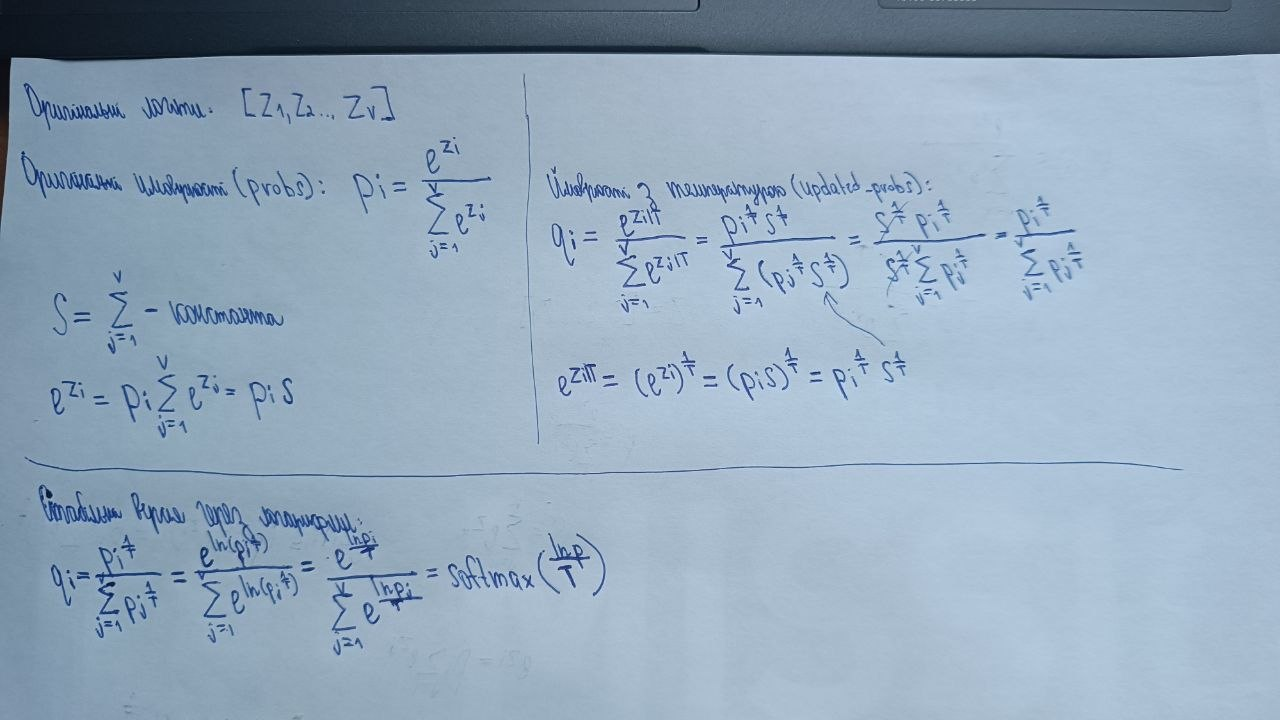

## Sampling with temperature

Ми також можемо впливати на генерацію параметром температури softmax.

Більші значення температури призводять до того, що різниця між ймовірностями токенів зменшується, тобто розподіл стає більш рівномірним. На практиці це означає, що менш ймовірні варіанти обиратимуться частіше і згенерований текст може бути цікавішим. Однак якщо продовжувати піднімати температуру, то текст спочатку втратить зв'язність, далі почнуть розпадатися слова та граматичність.

Менші значення температури змінюють розподіл таким чином, що основна ймовірніста маса припадає на невелику кількість топових токенів. При температурі 0 вся ймовірність дістанеться одному токену й семплінг перетвориться на greedy decoding.

Згенеруємо тексти з різною температурою:

In [91]:
for temperature in (0.1, 0.3, 0.5, 0.8, 1.0, 1.25, 1.5, 2.0, 3.0, 5.0):

    def sample_with_temp(probs):
        #powered_probs = probs.pow(1 / temperature)
        #updated_probs = powered_probs / powered_probs.sum()
        updated_probs = torch.softmax(probs.log() / temperature, dim = -1) #(probs + 1e-12)
        return simple_sample(updated_probs)

    print(f"Sampling with temperature={temperature}")
    result = generate(model, tokenizer, sample_with_temp, max_len=15)
    print(result)
    print()

Sampling with temperature=0.1
<|endoftext|>
The first time I saw the new version of the game, I

Sampling with temperature=0.3
<|endoftext|>
The following is a list of all the major players in the NBA

Sampling with temperature=0.5
<|endoftext|>"I'm not a fan of the idea of a caliphate," he

Sampling with temperature=0.8
<|endoftext|>1. That's why it's time to rise up," Ludd

Sampling with temperature=1.0
<|endoftext|> Enable auto which allocates to : id ( non-blocking) ,

Sampling with temperature=1.25
<|endoftext|>Sort Items First Price Lowest Price Highest Price Lowest Qty Highest

Sampling with temperature=1.5
<|endoftext|>Martin Wall Podcast PopularEvery SummerLakehurstSec: CLASS Nerity Northwestern

Sampling with temperature=2.0
<|endoftext|>Fullbury withdrawal Peper & Lect substrate david Laure the form blade Ltd

Sampling with temperature=3.0
<|endoftext|> confrontation yesterday mythologyrain Eth RiotohydLeft forms linguistic Wesley91 Restrict�

Sampling with temperature=5.0
<

In [92]:
# Яке значення `temperature` здається вам оптимальною?
lab.checkpoint("softmax temperature", 1.0)

Відповідь правильна ✅
Окей, добре


1.0

## Top-k sampling

In [93]:
def top_k_sampling(probs, k):
    topk = probs.topk(k)
    index = torch.multinomial(topk.values, num_samples=1)[0]
#     print(f"Top {k} words take {topk.values.sum():%} probability mass")
    return topk.indices[index]

In [94]:
k = 15
sample_fn = lambda probs: top_k_sampling(probs, k=k)
for i in range(1, 6):
    result = generate(model, tokenizer, sample_fn, max_len=20)
    print(f"#{i}: {result}")
    print()

#1: <|endoftext|>
By

As we've seen repeatedly with the current state of the Republican Party, there

#2: <|endoftext|>
The American public has been divided on the Affordable Care Act, with a majority saying the legislation

#3: <|endoftext|>
The US Navy's "Manned Maneuver" is an underwater surface-to-

#4: <|endoftext|>The American people are going to have a hard time seeing Donald Trump at his best, despite the

#5: <|endoftext|>"If you do a good job doing so, you're helping me to keep the company in



## Nucleus (top-p) sampling

In [95]:
def nucleus_sampling(probs, max_p):
    sorted_probs = probs.sort(descending=True)
    cum_prob = 0.0
    sample_indices = []
    sample_probs = []
    for i in range(0, len(sorted_probs.values)):
        p = sorted_probs.values[i]
        cum_prob += p
        sample_probs.append(p)
        sample_indices.append(sorted_probs.indices[i])
        if cum_prob >= max_p:
            break

    index = torch.multinomial(torch.tensor(sample_probs), num_samples = 1)[0]
    return sample_indices[index]

In [96]:
for max_p in (0.0, 0.1, 0.3, 0.5, 0.6, 0.8, 1.0):
    sample_fn = lambda probs: nucleus_sampling(probs, max_p=max_p)
    result = generate(model, tokenizer, sample_fn, max_len=20)
    print(f"#{max_p}: {result}")
    print()

#0.0: <|endoftext|>
The first time I saw the new version of the game, I was so excited. I

#0.1: <|endoftext|>The U.S. government has been trying to get the United Nations to stop the sale of

#0.3: <|endoftext|>The Department of Justice has announced that it will begin prosecuting people who have been convicted of sexual assault

#0.5: <|endoftext|>Worse, there's been a huge influx of immigrants from countries like the Philippines, Bangladesh,

#0.6: <|endoftext|>Other > !Other > !Other > !Other > !Other > !Other > !Other

#0.8: <|endoftext|>Fahrenheit 451, then the scientific motto of an anti-vaccination movement called the "

#1.0: <|endoftext|>War has gripped every war of their night - virtual & real

Which created a rebellion that



## Start from prompt

До цього моменту ми генерували текст з нуля. Однак значно кориснішим є задача генерації тексту від певного префікса або "підказки" -- в англійській мові це називається "prompt".

Prompt дозволить нам контролювати тематику згенерованого тексту або, як ми побачимо на іншій лекції, допоможе моделі виконувати різноманітні завдання.

In [97]:
@torch.no_grad()
def generate(model, tokenizer, sample_fn, prompt, max_len=50, bpe_decode=True):

    result = tokenizer.encode(prompt)
    print(tokenizer.encode(prompt))
    while len(result) < max_len:

        # Передбачення ймовірностней наступного токена
        input_ = torch.LongTensor([result])
        output = model(input_)
        log_probs = torch.log_softmax(output.logits[0, -1], dim=-1)

        # Обираємо токен, що має найбільшу ймовірність
        token_index = sample_fn(log_probs.exp())

        # Зупиняємося, якщо досягнули кінця
        if token_index == tokenizer.eos_token_id:
            break

        # Додаємо обраний токен в згенерований текст
        result.append(token_index.item())

    if bpe_decode:
        tokens = tokenizer.convert_ids_to_tokens(result)
        result = tokenizer.convert_tokens_to_string(tokens)

    return result

In [98]:
k = 3
sample_fn = lambda probs: top_k_sampling(probs, k=k)
for i in range(1, 5):
    result = generate(model, tokenizer, sample_fn, prompt="One of my favorite things is")
    print(f"#{i}: {result}")
    print()

[3198, 286, 616, 4004, 1243, 318]
#1: One of my favorite things is that I can do a lot of things with my phone. I can get to the point where I can use the phone and I can do things with it that I wouldn't have done with a tablet. I can do

[3198, 286, 616, 4004, 1243, 318]
#2: One of my favorite things is that it's not just about the game. It's about how it's going to be played. I think it's going to be a lot of fun. I think it's going to be a great experience. I

[3198, 286, 616, 4004, 1243, 318]
#3: One of my favorite things is that you have to have a lot of people around you who are going to be able to talk to each other, and you're going to get along with each other, and that's a great feeling."

"

[3198, 286, 616, 4004, 1243, 318]
#4: One of my favorite things is when you're in the middle of a game, you can't help but notice how much better it is to be able to see the difference between the two.

"You know, I've always been able to



# Zero-shot класифікація

Ми будемо досліджувати цю тему на окремій лекції. Але спробуємо застосувати мовну модель для задачі класифікації вже зараз. Хоча наша модель надто маленька й слабка для серйозного використання в zero-shot.


In [99]:
generate(model, tokenizer, greedy_choice, prompt="This film is awful! Actor play is terrible. The plot is dull. On the scale of 1 to 5 I would rate it as a").splitlines()[0]


[1212, 2646, 318, 12659, 0, 27274, 711, 318, 7818, 13, 383, 7110, 318, 19222, 13, 1550, 262, 5046, 286, 352, 284, 642, 314, 561, 2494, 340, 355, 257]


'This film is awful! Actor play is terrible. The plot is dull. On the scale of 1 to 5 I would rate it as a 5.'

In [100]:
generate(model, tokenizer, greedy_choice, prompt="This film is amazing! The time flies by when you watch it. Definitely recommend! On the scale of 1 to 5, I would rate it as a").splitlines()[0]


[1212, 2646, 318, 4998, 0, 383, 640, 17607, 416, 618, 345, 2342, 340, 13, 33562, 4313, 0, 1550, 262, 5046, 286, 352, 284, 642, 11, 314, 561, 2494, 340, 355, 257]


'This film is amazing! The time flies by when you watch it. Definitely recommend! On the scale of 1 to 5, I would rate it as a 5.'

In [101]:
lab.answer("Готово!")

Відповідь правильна ✅
Сподіваюсь, ця лаба була не надто важкою :)


'Готово!'

# Real world

У цій роботі ми імплементували кілька методів декодінгу. Але, звичайно, все вже зроблено за нас.

Подивіться на параметри функції [generate()](https://huggingface.co/docs/transformers/v4.21.1/en/main_classes/text_generation#transformers.generation_utils.GenerationMixin.generate) з бібліотеки transformers. Багато з них мають виглядати знайомими.

Повний приклад використання:

In [102]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model = AutoModelForCausalLM.from_pretrained("gpt2")
tokenizer = AutoTokenizer.from_pretrained("gpt2")

prompt = "I hope that in that practical class on text generation you"

inputs = tokenizer(prompt, return_tensors="pt")
outputs = model.generate(**inputs, do_sample=True, top_p=0.8, max_length=50)

tokenizer.batch_decode(outputs, skip_special_tokens=True)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

["I hope that in that practical class on text generation you will not have to worry about getting bored with a word or two later. But it's also important to be aware of how much of your brain is made up of tiny bits of data. The"]

# The End


In [103]:
lab.answer("Готово!")

Відповідь правильна ✅
Сподіваюсь, ця лаба була не надто важкою :)


'Готово!'